# Imports, installing stuff

In [ ]:
! pip install ftfy regex tqdm
! pip install git+https://github.com/openai/CLIP.git

import clip
import torch
import numpy as np
import matplotlib.pyplot as plt # who knows maybe we'll need it later on
import copy
from tqdm import tqdm
import random
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 1.9 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-8lcec2x_
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-8lcec2x_
  Resolved https://github.com/openai/CLIP.git to commit a1d071733d7111c9c014f024669f959182114e33
  Preparing metadata (setup.py) ... done
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl (121.6 MB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_

# Load model

In [ ]:
def load():

    # Load the model
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model, preprocess = clip.load('ViT-B/32', device)

    # model = convert_model_parameters_to_float32(model).to(device)

    # We just need the testing dataset. "preprocess" function of clip deals with the transformation of an image into a tensor, so
    # we don't have to worry about it applying some transformation to the dataset.

    cifar100 = torchvision.datasets.CIFAR100(root= './data', download = True, train = False)

    return cifar100, model, device, preprocess


In [ ]:
cifar100, model, device, preprocess = load()

#Tokenize the text labels
text_inputs = torch.cat([clip.tokenize(f"a photo of a {c}") for c in cifar100.classes]).to(device)

#Encoded text
with torch.no_grad():
  text_features = model.encode_text(text_inputs)

text_features /= text_features.norm(dim=-1, p = 2, keepdim=True)


100%|████████████████████████████████████████| 338M/338M [00:03<00:00, 115MiB/s]


100%|██████████| 169001437/169001437 [00:13<00:00, 12617797.15it/s]


Extracting ./data/cifar-100-python.tar.gz to ./data


# CLIP

In [ ]:
def marginal_entropy(logits):

    z = logits - logits.logsumexp(dim = -1, keepdim=True)     # compute z_ij
    marginal_logp = z.logsumexp(dim=0) - np.log(z.shape[0])   # compute marginal log probabilities

    min_real = torch.finfo(marginal_logp.dtype).min          # for numerical stability, The smallest representable number given the dtype of logits.
    avg_logits = torch.clamp(marginal_logp, min = min_real)  # put a threshold to avoid underflow

    return -(avg_logits * torch.exp(avg_logits)).sum(dim=-1)

In [ ]:
def predict(model, image, text_features, label):

    model.eval()
    image_prep = preprocess(image).unsqueeze(0).to(device)

    with torch.no_grad():

        image_features = model.encode_image(image_prep) # image features contains the embeddings of all the elements of the class.
        image_features = image_features / image_features.norm(dim = -1, keepdim = True)
        outputs = 100.0 * image_features @ text_features.T

        _, predicted = outputs.max(1)
        confidence = nn.functional.softmax(outputs,dim=1).squeeze()[predicted].item()

    correctness = 1 if predicted.item() == label else 0

    return correctness, confidence

# Plot tensor

In [ ]:
def plot_tensor(tensor_list, title = None, color = 'skyblue'):

    n = len(tensor_list)

    if n == 1:

      tensor = tensor_list[0]

      indices = torch.arange(len(tensor)).to(device)
      plt.bar(indices.cpu().detach().numpy(), tensor.detach().cpu().numpy(), color = color)
      plt.xlabel('Index')
      plt.ylabel('Value')
      plt.title(title)
      plt.grid(True)
      plt.show()

    else:
      fig, axs = plt.subplots(1, n, figsize=(15, 5))

      for i in range(n):
        data = tensor_list[i]
        indices = torch.arange(len(data)).to(device)
        # Plot histograms
        axs[i].bar(indices.cpu().detach().numpy(), data.cpu().detach().numpy(), color='blue', alpha=0.5)
        axs[i].set_title(title[i])
        axs[i].set_xlabel('Index')
        axs[i].set_ylabel('Value')

      # Adjust layout
      plt.tight_layout()

      # Show the plot
      plt.show()

So approximatively 90% of times CLIP cosine similarities contain in the first top 10 values the correct label.

# Specific augmentations of specific

In [ ]:
def augment_image(image, preprocess, num_augmentations = 100):

  # apply some random transformations
    augmentations = transforms.Compose([
        #transforms.RandomHorizontalFlip(p=0.5),
        #transforms.RandomVerticalFlip(p=0.5),
        #transforms.RandomRotation(degrees=30),
        #transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),
        transforms.RandomResizedCrop(size=224, scale=(0.08, 1.0), ratio=(0.75, 1.333)),
    ])
    #Add x0 without any augmentation
    # augmented_images = [preprocess(image).unsqueeze(0).to(device)]
    augmented_images = []

    #Add n augmentations to the augmented_images
    for _ in range(num_augmentations):
        augmented_images.append( preprocess(augmentations(image)).unsqueeze(0).to(device) )

    #Save it as a tensor
    batch = torch.vstack(augmented_images)

    return batch

# Hot stuff - functions

In [ ]:
def pick_candidates(tensor, classifier, num_candidates):

    _, top_indices = torch.topk(classifier, num_candidates)
    candidates = torch.squeeze(tensor[top_indices])

    return candidates, top_indices

def expand_tensor(tensor, top_indices, n):

    exp_tensor = torch.zeros(n).to(device)
    for i in range(top_indices.shape[0]): exp_tensor[top_indices[i]] = tensor[i]

    return exp_tensor



def compute_similarities(tensor1, tensor2, softmax = True):

  similarities = 100.0 * tensor1 @ tensor2.T
  if softmax: similarities = similarities.softmax(dim = -1).squeeze()
  return similarities


def generate_augmentations_similarities(image, image_features, txt_candidates, num_augmentations, aug_num = 5):

    # augment
    batch = augment_image(image, preprocess, num_augmentations = num_augmentations)
    aug_img_features = model.encode_image(batch)
    aug_img_features = aug_img_features / aug_img_features.norm(dim = -1, p = 2, keepdim = True)

    # pick the ones closest to the original image
    similarities_aug = compute_similarities(image_features, aug_img_features)
    aug_img_features, top_indices_aug = pick_candidates(aug_img_features, similarities_aug, num_candidates = aug_num)

    aug_similarities = compute_similarities(aug_img_features, txt_candidates)

    del batch # avoid Cuda to run out of memory?
    return torch.mean(aug_similarities, dim=0)


def boost_augmentations(image, image_features, text_features, prob, num_augmentations = 50, num_candidates = 3):

    _, top_indices = torch.topk(prob, num_candidates)
    text_candidates = text_features[top_indices]

    n = prob.shape[0]

    new_img_prob = compute_similarities(image_features, text_candidates)
    new_img_prob = expand_tensor(new_img_prob, top_indices, n)

    new_aug_prob = generate_augmentations_similarities(image, image_features, text_candidates, num_augmentations)
    new_aug_prob = expand_tensor(new_aug_prob, top_indices, n)

    return new_img_prob, new_aug_prob



# Hot stuff - main function

In [ ]:
def entropyboosting(image, text_features, device, label, preprocess, num_augmentations = 100, txt_num = 10, aug_num = 15, plot = False):

    image_prepro = preprocess(image).unsqueeze(0).to(device)

    image_features = model.encode_image(image_prepro)
    image_features = image_features / image_features.norm(dim = -1, p = 2, keepdim = True)

    img_prob = compute_similarities(image_features, text_features)

    aug_similarities = torch.empty(0)
    aug_prob = None

    num_candidates = 10
    output_prob = img_prob.clone()

    phi = 2 / (1 + np.sqrt(5)) # Aura section - math fetish but it seems to work so...
    _, running_predict = torch.topk(output_prob, 1)

    max_iter = 15
    iter = 0
    while iter < max_iter:

      new_img_prob, new_aug_prob = boost_augmentations(image, image_features, text_features, output_prob, num_augmentations = num_augmentations, num_candidates = num_candidates)

      img_prob = phi * img_prob + (1 - phi) * new_img_prob

      if aug_prob == None: aug_prob = new_aug_prob
      else:                aug_prob = 0.5 * aug_prob + 0.5 * new_aug_prob

      output_prob = 0.6 * img_prob + 0.4 * aug_prob # give a little more weight to the probability of the image.

      _, predict_step = torch.topk(output_prob, 1)

      # if running_ppredict != predict_step then it changed its mind: the class with highest probability has changed - better do further checks.
      if running_predict == predict_step: break

      running_predict = predict_step
      # num_candidates = int(num_candidates / 2)

      if num_candidates <= 1: break
      iter += 1

    correctness = 1 if running_predict == label else 0

    # del aug_prob, img_prob, output_prob, image_features

    return correctness


# Test

In [ ]:
n = 100
correct_select = 0
correct_clip = 0

start = random.randint(0, 5000)
start = 4714
print(f'Starting at {start}')

good_swap = 0
bad_swap  = 0

seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

for i in tqdm(range(n)):

  image, label = cifar100[i]

  cs = entropyboosting(image, text_features, device, label, preprocess, plot = False)
  cc, _ = predict(model, image, text_features, label = label)

  correct_select += cs
  correct_clip += cc

  if cc > cs:
    print(f'changed for the bad {i}')
    bad_swap += 1
  if cc < cs:
    print(f'changed for the good {i}')
    good_swap +=1



acc_select = round(100 * correct_select / n, 2)
acc_clip   = round(100 * correct_clip / n, 2)
print(f'Accuracy: clip: {acc_clip}%, select: {acc_select}%')
print(f'Changed idea for good: {good_swap}. Changed idea for bad {bad_swap}')

Starting at 4714


  0%|          | 0/100 [00:00<?, ?it/s]/usr/local/lib/python3.10/dist-packages/torch/nn/modules/conv.py:456: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return F.conv2d(input, weight, bias, self.stride,
  1%|          | 1/100 [00:01<03:17,  1.99s/it]

changed for the good 0


  3%|▎         | 3/100 [00:02<01:13,  1.32it/s]

changed for the good 2


 14%|█▍        | 14/100 [00:05<00:36,  2.38it/s]


KeyboardInterrupt: 

# Low entropy as a consequence - Entropy boost

MEMO algorithm relies on lowering the entropy in order to improve predictions, as the loss function is tailored explicitly for this purpose. *Low entropy is synonim of confident prediction*, which should provide robustness (or rather, *consistency*) under domain shifts, which is the problem tackled in this project.

However, even though low entropy values are desirable to have, they should be obtained as a *consequence* of the testing algorithm rather than than the target of the process itself, as in principle confident predictions does not imply correct ones.

Even though it would be wizardry (or cheating) to have any indication about how good (i.e. accurate) the prediction is without knowing the real label, working on robustness seems a path worth undertaking: that's where the major effort on this project is done.

The algorithm here presented is developed starting from the following remarks:


*   Augmentations are a crucial tool to improve stability under domain shifts, but helpful only if they're "good ones"
*   Zero-shot prediction doesn't make miracles: it's possible to make a difference only in high uncertainty scenarios, where the target is to change (hopefully for the good) the outcome of the raw output, or reinforcing the confidence in the prediction.
*   Training is out of the scope: it makes the prediction slow, and potentially damaging the model's structure.



## How to choose good augmentations?

The answer of this question is highly non trivial, as extracting the *right* features from the image itself is a hard task. Applying multiple transformations to the original image simultaneusly may lead to augmentations that have almost nothing in common with the original, hence potentially dangerous when it comes to classification.

A possible solution would be to rely on external models to "wisely" choose the most meaningful parts of the image. However, such models, like I-JEPA, are too heavy to be imported and hence we decided not to use them for this work. Instead, it is proposed a faster and simpler alternative.

*Finding good augmentations is equivalent of having a metric that evaluates the augmentations themselves*. For this purpose, we propose to *select augmentations whose embeddings are closest to the original image's one*. Given that transformations within a neural network are all continuous, this proximity in embedding space indicates that the closest augmentations retain more knolwedge of the original image.

Clearly, such an algorithm can make the difference only in a scenario with high uncertainty. In fact, if the image embedding lies close to a decision boundary between multiple labels, then considering where its closest augmentations lie may *suggest* which label to choose. In this scenario, it is unnecessary to consider labels with low cosine similarity scores, as they are far from the image embedding.

Since CLIPs embeddings are all normalized (with respect to the $p = 2$ norm) it's worth mentioning that

$$
\| x - y \|^2 = ( x-y, x-y) = \|x\|^2 + \|y\|^2 - 2(x , y) = 2( 1 - (x,y) )
= 2(1 - \text{sim}(x,y) )
$$

hence the lower the distance, the higher the cosine similarity.


Moreover, focusing only on the top-scoring labels (got from a first raw test of the original image) is more efficient and reduces computational complexity. By ignoring low-scoring labels, the probability distributions will involve only a few candidates, therefore making the process computationally more efficient thus lowering the *entropy* of the probability distributions that now involve just a few components.

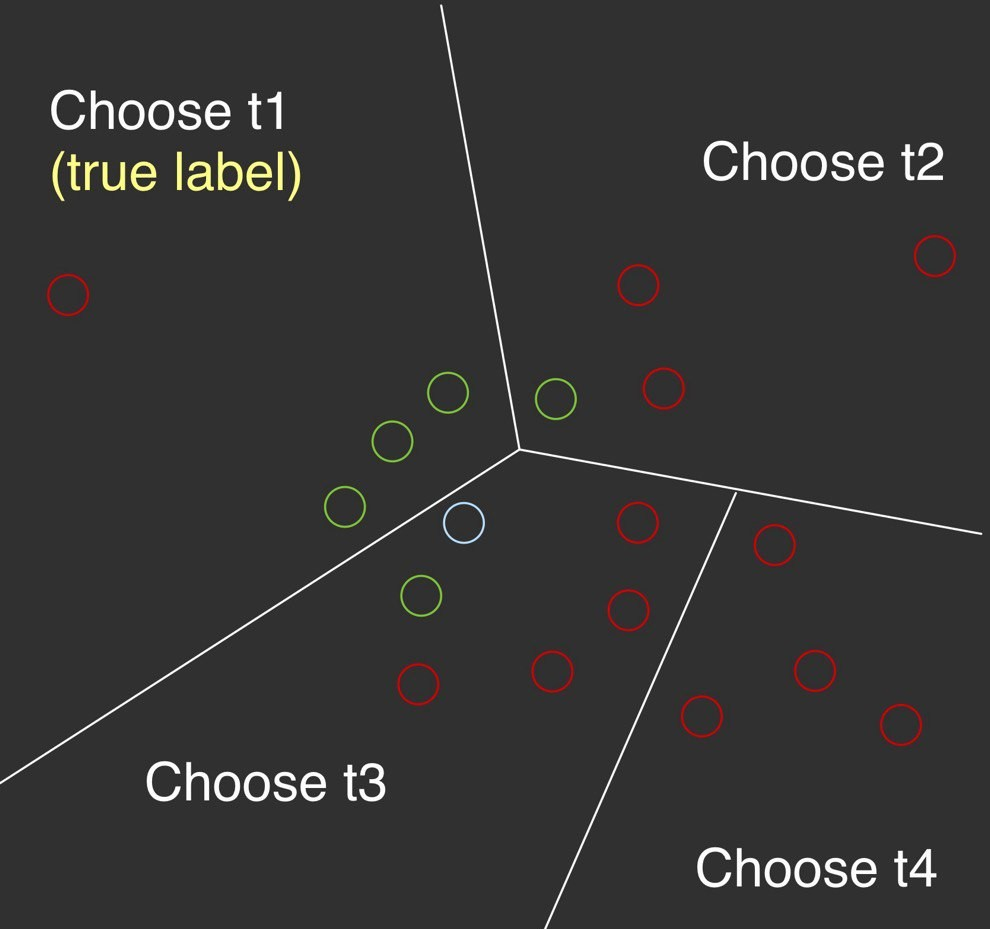

As for the image above:

*   white dot is the image embedding
*   green dots are the 5 augmentation embeddings closest to the image
*   red dots are the augmentation embeddings further away

## Algorithm

The algorithm works the following way:

1. Compute the image embedding, namely ```image_features ```, and calculate the probability distribution,  ```img_prob ```, over all the classes.
2. Generate  ```num_augmentations ``` image augmentations.
3. Select the closest labels (```candidates ```) and closest augmentation embeddings to the ```image_features ```.
4. Compute the average probability distribution of the closest augmentation embeddings over the candidates, defined as ```aug_prob ```.
5. Enhance the probabilities of  ```candidates ``` in  ```img_prob ``` by taking a convex combination between the original  ```img_prob ``` and the probability distribution of the image over  ```candidates ``` only. For simplicity call this output still ```img_prob ```.
6. Take a convex combination between ```img_prob ``` and ```aug_prob ```. The resulting probability distribution is called ```output_prob ```.


Step 5. may seem a bit odd, but it's necessary as the average between ```img_prob ``` and ```aug_prob ``` at step 6. is not "fair" in the sense that
```img_prob ``` is a probability over all the labels - thus having a lot of noise caused by all the low scoring ones -, whilst ```aug_prob ``` involves just ```candidates ```.

In order to choose only augmentations closest to the original imge, the transformations applied are just random crops.

This latter observation highlights a relevant component on most of augmentation-based algorithms: *augmentations are not deterministic*. Hence the outcome of the same test prediction may differ based on which augmentations are generated. Clearly, generating as many augmentations as possible would alleviate this problem, at the expense of time and memory usage.

For this reason, we induce a layer of complexity in the algorithm to deal with it:



*   If ```output_prob ``` has as highest scoring candidate the same label of the original ```img_prob```, then it suggest that both ```img_prob``` and ```aug_prob``` agree in picking the same label. In this case, the algorithm ends.
*   If, instead, ```output_prob ``` highest scoring candidate is different from ```img_prob``` one it means that ```aug_prob ``` propends for another label. Since this latter probability distribution is highly influenced by the *random* augmentations, it's wise to generate other augmentations as they increase the reliability of the prediction. So then the process is repeated again. At this point the new ```aug_prob ``` is averaged between past and current iterations. If the output of ```output_prob ``` of the past iteration is equal to the one of the current one, the algorithm ends. Otherwise, go for another sweep and repeat the process.




# Visual example - NO NO

trout


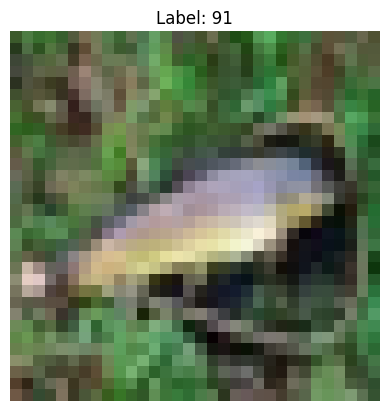

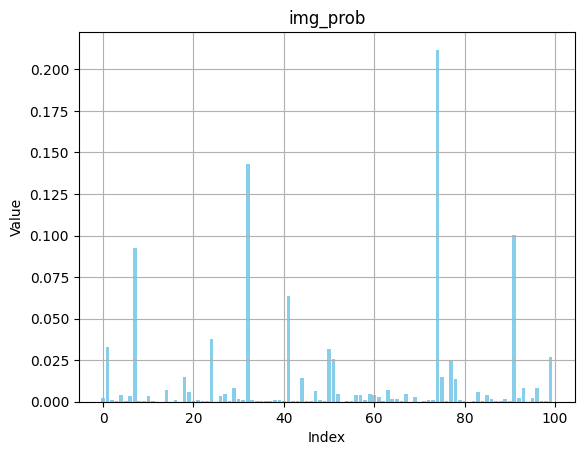

In [ ]:
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

image, label = cifar100[73]

print(cifar100.classes[label])

plt.imshow(image)
plt.title(f'Label: {label}')
plt.axis('off')
plt.show()

num_augmentations = 50
aug_num = 3
num_candidates = 10

image_prepro = preprocess(image).unsqueeze(0).to(device)

image_features = model.encode_image(image_prepro)
image_features = image_features / image_features.norm(dim = -1, p = 2, keepdim = True)

img_prob = compute_similarities(image_features, text_features)

aug_similarities = torch.empty(0)
aug_prob = None

plot_tensor([img_prob], 'img_prob')

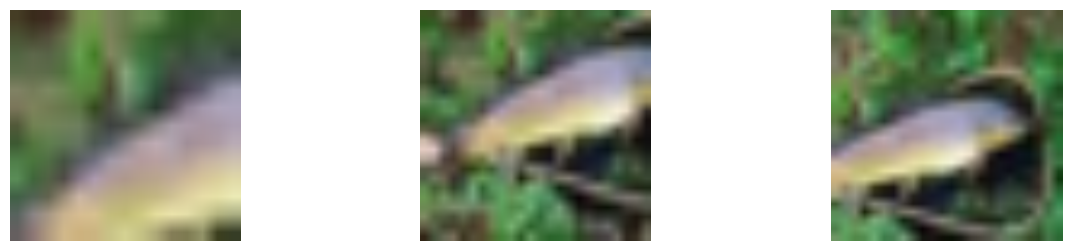

In [ ]:

num_candidates = 10
output_prob = img_prob.clone()

_, top_indices = torch.topk(output_prob, num_candidates)
text_candidates = text_features[top_indices]

# apply some random transformations
augmentations = transforms.Compose([transforms.RandomResizedCrop(size=224, scale=(0.08, 1.0), ratio=(0.75, 1.333)),])
augmented_images = [] # these are already preprocessed
augmented_raw_images = []

#Add n augmentations to the augmented_images
for _ in range(num_augmentations):
  augmented_images.append( preprocess(augmentations(image)).unsqueeze(0).to(device) )
  augmented_raw_images.append(augmentations(image))


#Save it as a tensor
batch = torch.vstack(augmented_images)

# augment
aug_img_features = model.encode_image(batch)
aug_img_features = aug_img_features / aug_img_features.norm(dim = -1, p = 2, keepdim = True)

# pick the ones closest to the original image
similarities_aug = compute_similarities(image_features, aug_img_features)
aug_img_features, top_indices_aug = pick_candidates(aug_img_features, similarities_aug, num_candidates = aug_num)

aug_similarities = compute_similarities(aug_img_features, text_features)

top_indices_aug = top_indices_aug.squeeze()
fig, axes = plt.subplots(1, aug_num, figsize=(15, 3))  # Adjust figsize as needed

for i in range(aug_num):

    image = augmented_raw_images[top_indices_aug[i]]
    axes[i].imshow(image)
    axes[i].axis('off')
